<a href="https://colab.research.google.com/github/MahdiMashayekhi-AI/Machine-Learning-Projects/blob/main/02-supervised-learning/01-classification/Heart-Attack-Prediction/Heart_Attack_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Heart Attack Prediction 🫀

### Feature descriptions:

1. age
2. sex
3. chest pain type (4 values)
4. resting blood pressure
5. serum cholestoral in mg/dl
6. fasting blood sugar > 120 mg/dl
7. resting electrocardiographic results (values 0,1,2)
8. maximum heart rate achieved
9. exercise induced angina
10. oldpeak = ST depression induced by exercise relative to rest
11. the slope of the peak exercise ST segment
12. number of major vessels (0-3) colored by flourosopy
13. thal: 0 = normal; 1 = fixed defect; 2 = reversable defect

## Importing libraries

In [2]:
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from kagglehub import KaggleDatasetAdapter
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

## Loading the dataset

In [3]:
# Set the path to the file you'd like to load
file_path = "heart.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "yasserh/heart-disease-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

100%|██████████| 11.1k/11.1k [00:00<00:00, 8.87MB/s]


In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.30,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.50,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.40,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.80,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.60,2,0,2,1


## Exploratory Data Analysis (EDA)

In [5]:
print(f"Number of rows in the dataset: {df.shape[0]}")
print(f"Number of columns in the dataset: {df.shape[1]}")

Number of rows in the dataset: 303
Number of columns in the dataset: 14


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [7]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [8]:
print(f"Total number of missing values in dataset is: {df.isnull().sum().sum()}")

Total number of missing values in dataset is: 0


In [9]:
print(f"Total number of duplicate values in dataset is: {df.duplicated().sum()}")

Total number of duplicate values in dataset is: 1


In [10]:
df[df.duplicated(keep=False)].sort_values(by=list(df.columns))

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
163,38,1,2,138,175,0,1,173,0,0.00,2,4,2,1
164,38,1,2,138,175,0,1,173,0,0.00,2,4,2,1


In [11]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00
mean,54.37,0.68,0.97,131.62,246.26,0.15,0.53,149.65,0.33,1.04,1.40,0.73,2.31,0.54
std,9.08,0.47,1.03,17.54,51.83,0.36,0.53,22.91,0.47,1.16,0.62,1.02,0.61,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,47.50,0.00,0.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,2.00,0.00
50%,55.00,1.00,1.00,130.00,240.00,0.00,1.00,153.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,274.50,0.00,1.00,166.00,1.00,1.60,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


In [12]:
corr_matrix = df.corr()
corr_matrix

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.00,-0.10,-0.07,0.28,0.21,0.12,-0.12,-0.40,0.10,0.21,-0.17,0.28,0.07,-0.23
sex,-0.10,1.00,-0.05,-0.06,-0.20,0.05,-0.06,-0.04,0.14,0.10,-0.03,0.12,0.21,-0.28
cp,-0.07,-0.05,1.00,0.05,-0.08,0.09,0.04,0.30,-0.39,-0.15,0.12,-0.18,-0.16,0.43
trestbps,0.28,-0.06,0.05,1.00,0.12,0.18,-0.11,-0.05,0.07,0.19,-0.12,0.10,0.06,-0.14
chol,0.21,-0.20,-0.08,0.12,1.00,0.01,-0.15,-0.01,0.07,0.05,-0.00,0.07,0.10,-0.09
fbs,0.12,0.05,0.09,0.18,0.01,1.00,-0.08,-0.01,0.03,0.01,-0.06,0.14,-0.03,-0.03
restecg,-0.12,-0.06,0.04,-0.11,-0.15,-0.08,1.00,0.04,-0.07,-0.06,0.09,-0.07,-0.01,0.14
thalach,-0.40,-0.04,0.30,-0.05,-0.01,-0.01,0.04,1.00,-0.38,-0.34,0.39,-0.21,-0.10,0.42
exang,0.10,0.14,-0.39,0.07,0.07,0.03,-0.07,-0.38,1.00,0.29,-0.26,0.12,0.21,-0.44
oldpeak,0.21,0.10,-0.15,0.19,0.05,0.01,-0.06,-0.34,0.29,1.00,-0.58,0.22,0.21,-0.43


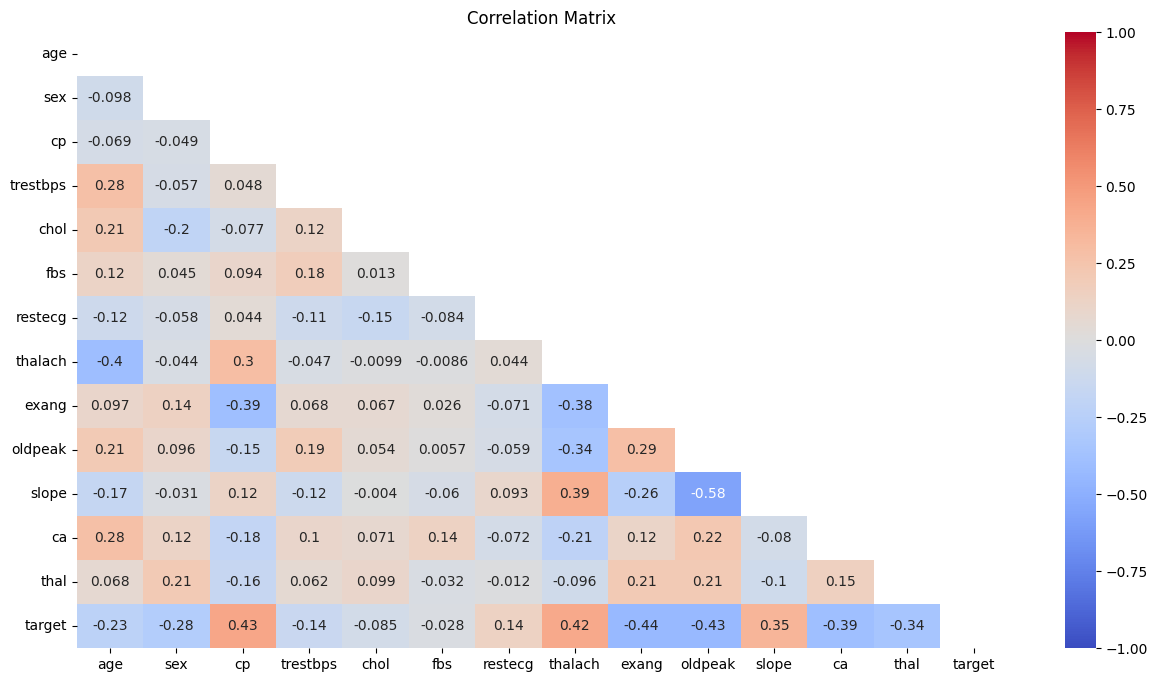

In [13]:
plt.figure(figsize=(15, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, vmin=-1, vmax=1, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

Check for imbalanced traget feature

In [14]:
df['target'].value_counts()

,count
target,
1,165
0,138


In [15]:
df['target'].value_counts(normalize=True)

,proportion
target,
1,0.54
0,0.46


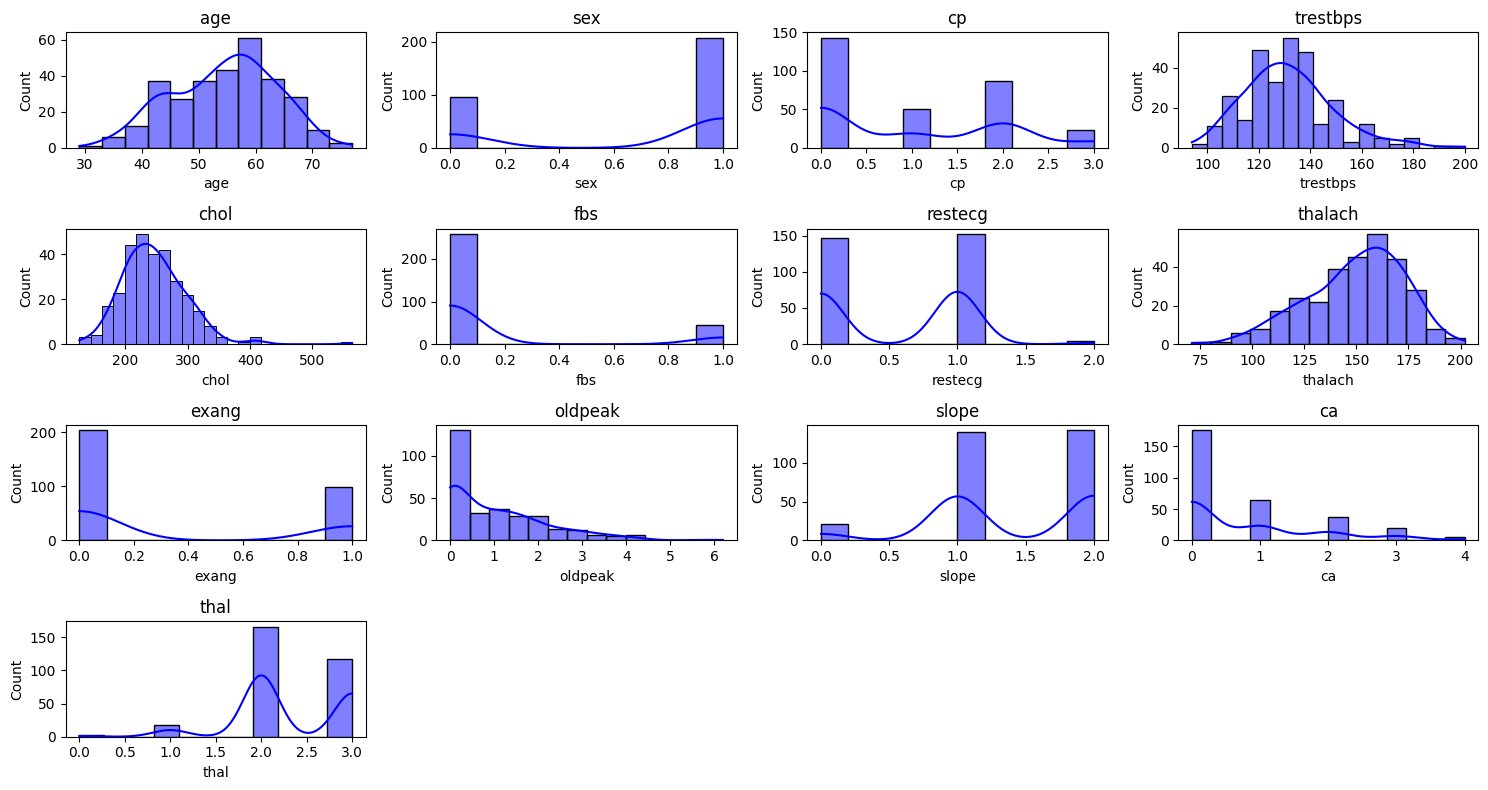

In [16]:
# Check the histogram of features
plt.figure(figsize=(15, 8))
for i, col in enumerate(df.columns[:-1]):
    plt.subplot(4, 4, i+1)
    sns.histplot(df[col], kde=True, color='b')
    plt.title(col)
plt.tight_layout()
plt.show()

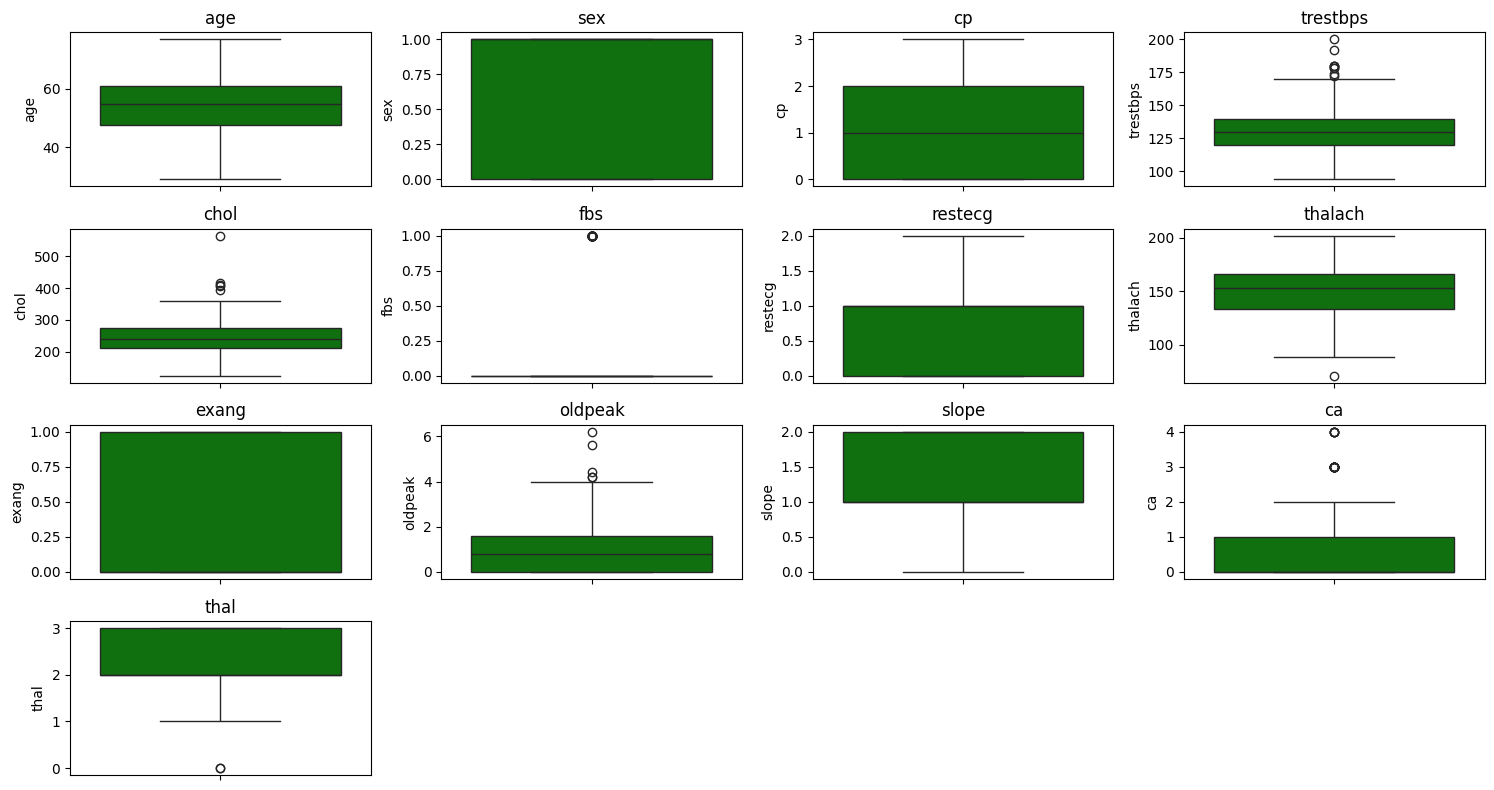

In [17]:
# Check for outliers
plt.figure(figsize=(15, 8))
for i, col in enumerate(df.columns[:-1]):
    plt.subplot(4, 4, i+1)
    sns.boxplot(df[col], color='g')
    plt.title(col)
plt.tight_layout()
plt.show()

## Data Preprocessing

### Splitting the dataset into train and

In [18]:
X = df.drop('target', axis=1)
y = df['target']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [20]:
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")

Shape of X_train: (242, 13)
Shape of X_test: (61, 13)


### Feature Scaling

In [21]:
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

## Train with 4 models

In [22]:
classifiers = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(criterion='entropy', random_state=42),
    'Naive Bayes': GaussianNB(var_smoothing=1e-9),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
}

In [23]:
def evaluate_model(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    return accuracy, precision, recall, f1

In [24]:
results = {}

for name, model in classifiers.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy, precision, recall, f1 = evaluate_model(y_test, y_pred)
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')
    results[name] = {'Accuracy': accuracy,
                     'Precision': precision,
                     'Recall': recall,
                     'F1 Score': f1,
                     'CV': scores.mean()}

    print(f"--- Model: {name} ---")
    print(f"Accuracy: {accuracy * 100:.2f}")
    print(f"Precision: {precision* 100:.2f}")
    print(f"Recall: {recall* 100:.2f}")
    print(f"F1 Score: {f1* 100:.2f}")
    print(f"Cross-Validation F1 Scores: {scores.mean() * 100:.2f}")
    print()

--- Model: Logistic Regression ---
Accuracy: 80.33
Precision: 76.92
Recall: 90.91
F1 Score: 83.33
Cross-Validation F1 Scores: 85.26

--- Model: Decision Tree ---
Accuracy: 75.41
Precision: 76.47
Recall: 78.79
F1 Score: 77.61
Cross-Validation F1 Scores: 74.03

--- Model: Naive Bayes ---
Accuracy: 81.97
Precision: 78.95
Recall: 90.91
F1 Score: 84.51
Cross-Validation F1 Scores: 82.22

--- Model: K-Nearest Neighbors ---
Accuracy: 80.33
Precision: 76.92
Recall: 90.91
F1 Score: 83.33
Cross-Validation F1 Scores: 82.64



In [25]:
result_df = pd.DataFrame(results).T.sort_values(by='CV', ascending=False)
result_df

,Accuracy,Precision,Recall,F1 Score,CV
Logistic Regression,0.80,0.77,0.91,0.83,0.85
K-Nearest Neighbors,0.80,0.77,0.91,0.83,0.83
Naive Bayes,0.82,0.79,0.91,0.85,0.82
Decision Tree,0.75,0.76,0.79,0.78,0.74


Logistic Regression has best cross validation score on F1 metrics

Let's create a logistic regression for evaluating test set

In [26]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [27]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [28]:
accuracy, precision, recall, f1 = evaluate_model(y_train, y_train_pred)
print(f"--- Model: 'Logistic Regression (Train set)' ---")
print(f"Accuracy: {accuracy * 100:.2f}")
print(f"Precision: {precision* 100:.2f}")
print(f"Recall: {recall* 100:.2f}")
print(f"F1 Score: {f1* 100:.2f}")

--- Model: 'Logistic Regression (Train set)' ---
Accuracy: 84.30
Precision: 82.64
Recall: 90.15
F1 Score: 86.23


In [29]:
accuracy, precision, recall, f1 = evaluate_model(y_test, y_test_pred)
print(f"--- Model: 'Logistic Regression (Test set)' ---")
print(f"Accuracy: {accuracy * 100:.2f}")
print(f"Precision: {precision* 100:.2f}")
print(f"Recall: {recall* 100:.2f}")
print(f"F1 Score: {f1* 100:.2f}")

--- Model: 'Logistic Regression (Test set)' ---
Accuracy: 80.33
Precision: 76.92
Recall: 90.91
F1 Score: 83.33


According to train and test result, the model is not overfitting.

## Fine-tuning the Logistic Regression

In [30]:
params = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

grid_search = GridSearchCV(LogisticRegression(), params, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'penalty': ['l1', 'l2'],
                         'solver': ['liblinear', 'saga']},
             scoring='f1')

In [31]:
print(f"Best params is: {grid_search.best_params_}")
print(f"BEst score is: {grid_search.best_score_}")
best_model = grid_search.best_estimator_

Best params is: {'C': 0.1, 'penalty': 'l1', 'solver': 'saga'}
BEst score is: 0.8734354526752568


In [32]:
y_grid_pred = best_model.predict(X_test)

In [33]:
accuracy, precision, recall, f1 = evaluate_model(y_test, y_grid_pred)
print(f"--- Model: 'Logistic Regression (Test set)' ---")
print(f"Accuracy: {accuracy * 100:.2f}")
print(f"Precision: {precision* 100:.2f}")
print(f"Recall: {recall* 100:.2f}")
print(f"F1 Score: {f1* 100:.2f}")

--- Model: 'Logistic Regression (Test set)' ---
Accuracy: 81.97
Precision: 76.19
Recall: 96.97
F1 Score: 85.33


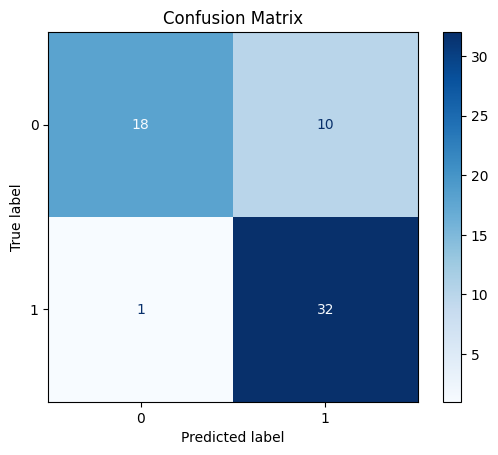

In [34]:
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_grid_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

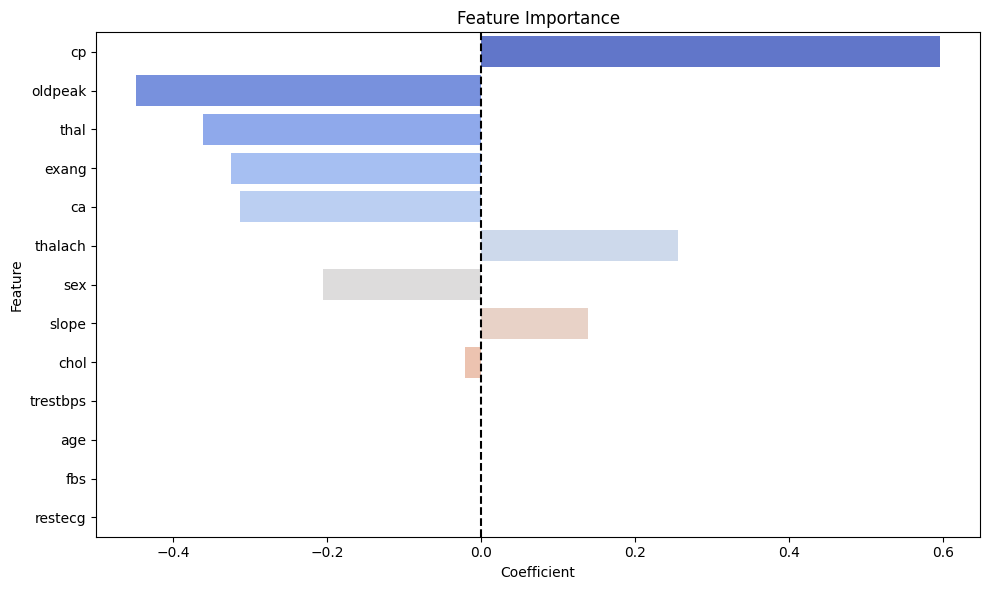

In [35]:
coefs = best_model.coef_[0]
features = X_train.columns

importance_df = pd.DataFrame({'Feature': features, 'Coefficient': coefs})
importance_df['Abs_Coefficient'] = np.abs(importance_df['Coefficient'])
importance_df = importance_df.sort_values('Abs_Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=importance_df, palette='coolwarm')
plt.title("Feature Importance")
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

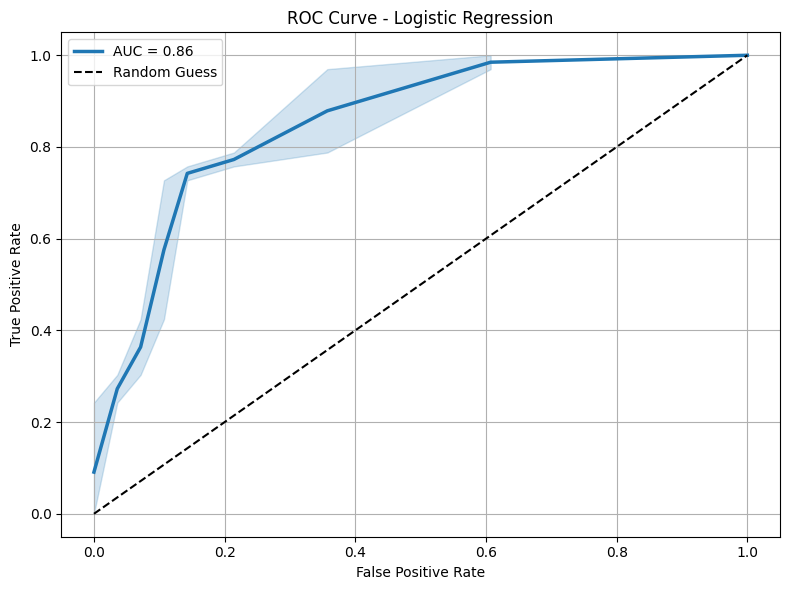

In [36]:
y_proba = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
sns.lineplot(x=fpr, y=tpr, label=f'AUC = {roc_auc:.2f}', linewidth=2.5)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [44]:
fpr

array([0.        , 0.        , 0.        , 0.03571429, 0.03571429,
       0.07142857, 0.07142857, 0.10714286, 0.10714286, 0.14285714,
       0.14285714, 0.21428571, 0.21428571, 0.35714286, 0.35714286,
       0.60714286, 0.60714286, 1.        ])

In [45]:
tpr

array([0.        , 0.03030303, 0.24242424, 0.24242424, 0.3030303 ,
       0.3030303 , 0.42424242, 0.42424242, 0.72727273, 0.72727273,
       0.75757576, 0.75757576, 0.78787879, 0.78787879, 0.96969697,
       0.96969697, 1.        , 1.        ])

In [46]:
thresholds

array([       inf, 0.96492182, 0.85155013, 0.84687914, 0.84507805,
       0.83752434, 0.8125141 , 0.81230514, 0.68726834, 0.67987726,
       0.6708794 , 0.66150119, 0.65718358, 0.59637365, 0.51114561,
       0.26693023, 0.25823788, 0.06671964])

In [47]:
for thr, t, f in zip(thresholds, tpr, fpr):
    print(f"Threshold: {thr:.2f} → TPR: {t:.2f}, FPR: {f:.2f}")

Threshold: inf → TPR: 0.00, FPR: 0.00
Threshold: 0.96 → TPR: 0.03, FPR: 0.00
Threshold: 0.85 → TPR: 0.24, FPR: 0.00
Threshold: 0.85 → TPR: 0.24, FPR: 0.04
Threshold: 0.85 → TPR: 0.30, FPR: 0.04
Threshold: 0.84 → TPR: 0.30, FPR: 0.07
Threshold: 0.81 → TPR: 0.42, FPR: 0.07
Threshold: 0.81 → TPR: 0.42, FPR: 0.11
Threshold: 0.69 → TPR: 0.73, FPR: 0.11
Threshold: 0.68 → TPR: 0.73, FPR: 0.14
Threshold: 0.67 → TPR: 0.76, FPR: 0.14
Threshold: 0.66 → TPR: 0.76, FPR: 0.21
Threshold: 0.66 → TPR: 0.79, FPR: 0.21
Threshold: 0.60 → TPR: 0.79, FPR: 0.36
Threshold: 0.51 → TPR: 0.97, FPR: 0.36
Threshold: 0.27 → TPR: 0.97, FPR: 0.61
Threshold: 0.26 → TPR: 1.00, FPR: 0.61
Threshold: 0.07 → TPR: 1.00, FPR: 1.00
